**Group Name:** Course Project Group 25

**Members:** 汪鸿源 72510222

# 5489 AIGC Detection Project - ViT-Base & ResNet-50

# Abstract

The project focuses on building a **practical AIGC image detector** under a realistic constraint: **binary classification (real vs. AI-generated) with only ~50,000 training images.** 

- **Initial Challenge:** At the beginning, I designed a **hybrid architecture combining ResNet-50, ViT-Base and a frequency-domain module.** Although this complex model achieved very high performance on the training and validation sets, it **severely overfitted** and generalized poorly to the test set **(Val_Accuracy = 0.9948 vs. Test_Accuracy = 0.8023).** There are numerous reasons for this outcome, one being the contradiction between the **model's enormous number of parameters** and the **relatively scarce training data** provided by the project.

- **Ablation Study:** To address this overfitting issue and to better understand the contribution of different components, I conducted a **systematic ablation study.** In this report, I focus on **two clean and representative backbones: ViT-Base and ResNet-50**, both operating purely in the RGB domain.

- **Methodology:** For both backbones, I adopt **transfer learning**: only the **last 4 encoder layers of ViT-Base** and the **last block (layer4) of ResNet-50** are fine-tuned, while earlier layers remain frozen. In addition, I integrate **strong data augmentation**, a **high-pass filter–based enhancement, Focal Loss with label smoothing, mixed-precision training, cosine learning rate scheduling**, and **early stopping** to improve robustness and generalization.

- **ResNet-50 only and ViT-Base only Results:** Experimental results **on the validation set** show that **ResNet-50 consistently outperforms ViT-Base** on this specific AIGC detection task in terms of **accuracy, precision, recall and F1 score**. However, **on the test set, ViT-Base achieves the better accuracy of 0.8845, while ResNet-50 attains 0.8159.**

**In summary**, this study reveals a significant trade-off between in-distribution performance and generalization. While **ResNet-50** excels at capturing local artifacts within the training distribution, **ViT-Base** demonstrates superior **generalization capabilities** to unseen data. This suggests that the global attention mechanism of Transformers learns more robust features for AIGC detection, making it a more practical choice for real-world deployment despite lower validation scores.

## 1. Initialization 

### 1.1 环境初始化与随机种子设置

这一部分主要完成：
- 导入基础训练所需的库（PyTorch、NumPy、可视化等）
- 设置 HuggingFace 镜像加速下载 ViT 预训练权重
- 选择运行设备（GPU / CPU）并打印硬件信息
- 固定随机种子，保证实验可复现

In [1]:
# 初始化环境与随机种子，保证实验可复现性
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
import matplotlib.pyplot as plt
import time
import os
import json
from tqdm.auto import tqdm
from torch.utils.tensorboard import SummaryWriter
from sklearn.metrics import precision_score, recall_score, f1_score
import warnings
warnings.filterwarnings('ignore')  # 忽略不影响实验结果的警告信息

# hf-mirror.com configuration：使用国内镜像加速 HuggingFace 预训练模型下载
os.environ['HF_ENDPOINT'] = 'https://hf-mirror.com'

# Device configuration：自动选择 GPU 或 CPU
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")
if device.type == 'cuda':
    # 打印 GPU 名称与显存大小信息
    print(f"GPU: {torch.cuda.get_device_name(0)}")
    print(f"Memory: {torch.cuda.get_device_properties(0).total_memory / 1024**3:.2f} GB")

# Random seed setting (for reproducibility)：设置随机种子，保证结果可重复
torch.manual_seed(42)
np.random.seed(42)
if device.type == 'cuda':
    torch.cuda.manual_seed_all(42)
    # 关闭 cuDNN 的非确定性优化，进一步提升可复现性
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

Using device: cuda
GPU: NVIDIA GeForce RTX 5090
Memory: 31.36 GB


### 1.2 数据增强、数据集定义与模型 / 训练工具封装

这一部分完成的主要工作：
- 定义一个高通滤波数据增强 `HighPassFilter`，用于强调高频伪造痕迹
- 构建自定义数据集 `EnhancedAIGCDataset`，从文件夹读取图像并自动推断标签
- 提供 `create_data_loaders` 函数，划分训练/验证集并返回 DataLoader
- 定义两个主干模型：`ViTForAIGC` 与 `ResNetForAIGC`，基于预训练模型进行微调
- 实现 `FocalLoss` 损失与 `MixedPrecisionTrainer` 训练器，支持混合精度训练、早停、TensorBoard 记录
- 使用 `create_optimizer_and_scheduler` 封装优化器和余弦退火学习率策略

In [2]:
# 数据增强、数据集定义、模型结构与训练工具
import cv2
import albumentations as A
from albumentations.pytorch import ToTensorV2
from torch.utils.data import Dataset, DataLoader, random_split
from transformers import ViTModel, ViTConfig
from torchvision.models import resnet50, ResNet50_Weights
from torch.cuda.amp import autocast, GradScaler
from torch.optim.lr_scheduler import CosineAnnealingLR
from typing import Dict, List, Tuple, Optional, Union
import numpy as np

# 频域特征：高通滤波模块，用于突出高频伪造痕迹
class HighPassFilter(A.ImageOnlyTransform):
    def __init__(self, always_apply=False, p=0.5):
        super(HighPassFilter, self).__init__(always_apply, p)

    def apply(self, img, **params):
        # 将 RGB 图像转换为灰度图
        gray = cv2.cvtColor(img, cv2.COLOR_RGB2GRAY)
        # 高斯模糊，用于提取低频部分
        blur = cv2.GaussianBlur(gray, (21, 21), 0)
        # 灰度图减去模糊结果，得到高频分量
        high_pass = cv2.subtract(gray, blur)
        # 将单通道高频图复制为 3 通道，方便与 RGB 流程对接
        high_pass_rgb = cv2.cvtColor(high_pass, cv2.COLOR_GRAY2RGB)
        return high_pass_rgb

# 增强版 AIGC 数据集，自动从目录结构中推断标签
class EnhancedAIGCDataset(Dataset):
    def __init__(self, image_dir: str, transform_rgb: Optional[object] = None, mode: str = 'train'):
        self.image_dir = image_dir
        self.mode = mode
        # 遍历文件夹下所有图像路径
        self.image_files = [
            os.path.join(dp, f)
            for dp, dn, fn in os.walk(os.path.expanduser(image_dir))
            for f in fn
            if f.endswith(('.png', '.jpg', '.jpeg'))
        ]
        
        # 根据路径中是否包含 'fake' 推断标签：fake -> 1，real -> 0
        self.labels = [1 if 'fake' in path else 0 for path in self.image_files]
        
        # 若未显式传入 transform，则按 mode 使用默认的数据增强
        self.transform_rgb = transform_rgb if transform_rgb else self._get_default_rgb_transform()

    def _get_default_rgb_transform(self):
        if self.mode == 'train':
            # 训练阶段使用增强策略，提高模型鲁棒性
            return A.Compose([
                # 使用 RandomResizedCrop 避免直接缩放导致的插值模糊，保留局部高频细节
                # 注意：size 需以 (height, width) 形式指定
                A.RandomResizedCrop(size=(224, 224), scale=(0.6, 1.0), ratio=(0.75, 1.333)),
                # 基本几何增强：水平 / 垂直翻转、随机旋转
                A.HorizontalFlip(p=0.5),
                A.VerticalFlip(p=0.5),
                A.Rotate(limit=30, p=0.5),
                
                # 噪声与颜色扰动：模拟多样化拍摄/生成条件
                A.GaussNoise(var_limit=(10.0, 50.0), p=0.5),  # 添加高斯噪声
                A.RandomBrightnessContrast(brightness_limit=0.2, contrast_limit=0.2, p=0.5),
                A.HueSaturationValue(hue_shift_limit=20, sat_shift_limit=30, val_shift_limit=20, p=0.5),
                
                # 压缩伪影与模糊：模拟不同压缩质量和成像模糊
                A.ImageCompression(quality_lower=30, quality_upper=90, p=0.5),  # 降低质量上限
                A.GaussianBlur(blur_limit=(3, 7), p=0.5),  # 增强模糊概率
                
                # 频域增强：有一定概率用高通滤波结果替代原图
                HighPassFilter(p=0.2),

                # CoarseDropout：随机遮挡局部区域，提升模型对局部缺失的鲁棒性
                A.CoarseDropout(
                    max_holes=8, max_height=32, max_width=32,
                    min_holes=1, min_height=8, min_width=8,
                    fill_value=0, p=0.5
                ),
                # 使用 ImageNet 均值方差做归一化，兼容预训练模型
                A.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
                ToTensorV2(),  # 转为 PyTorch Tensor，通道顺序为 C×H×W
            ])
        else:
            # 验证 / 测试阶段仅做 Resize + Normalize，保持评估一致性
            return A.Compose([
                A.Resize(224, 224),
                A.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
                ToTensorV2(),
            ])

    def __len__(self) -> int:
        # 返回样本总数
        return len(self.image_files)

    def __getitem__(self, idx: int) -> Dict[str, Union[torch.Tensor, str]]:
        # 根据索引读取一张图像并返回其张量与标签
        img_path = self.image_files[idx]
        image = cv2.imread(img_path)
        image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
        
        # 对 RGB 图像应用数据增强
        transformed_rgb = self.transform_rgb(image=image)['image']
        
        label = self.labels[idx]
        
        return {
            'rgb': transformed_rgb,                           # 增强后的 RGB 图像
            'label': torch.tensor(label, dtype=torch.long),   # 二分类标签（0: real, 1: fake）
            'filename': os.path.basename(img_path)            # 图像文件名
        }

# 构建训练 / 验证 DataLoader
def create_data_loaders(train_dir: str, batch_size: int, num_workers: int, val_ratio: float = 0.1) -> Dict[str, DataLoader]:
    # 加载完整训练集（暂不划分 train / val）
    full_train_dataset = EnhancedAIGCDataset(image_dir=train_dir, mode='train')
    
    total_size = len(full_train_dataset)
    val_size = int(total_size * val_ratio)   # 验证集样本数
    train_size = total_size - val_size       # 训练集样本数
    
    # 使用 random_split 根据索引划分训练 / 验证集
    train_dataset, val_dataset = random_split(full_train_dataset, [train_size, val_size])
    
    # 为验证集切换到 "val" 模式，并使用更简单的变换
    val_dataset.dataset.mode = 'val'
    val_dataset.dataset.transform_rgb = val_dataset.dataset._get_default_rgb_transform()
    
    dataloaders = {
        'train': DataLoader(train_dataset, batch_size=batch_size, shuffle=True,  num_workers=num_workers, pin_memory=True),
        'val':   DataLoader(val_dataset,   batch_size=batch_size, shuffle=False, num_workers=num_workers, pin_memory=True)
    }
    return dataloaders

# --- ViT-Base model ---
class ViTForAIGC(nn.Module):
    def __init__(self, num_classes: int = 2, pretrained: bool = True):
        super().__init__()
        model_name = "google/vit-base-patch16-224-in21k"
        # pretrained=True 时从 HuggingFace 加载预训练权重
        self.vit = ViTModel.from_pretrained(model_name) if pretrained else ViTModel(ViTConfig.from_pretrained(model_name))

        if pretrained:
            # 先冻结所有参数
            for param in self.vit.parameters():
                param.requires_grad = False
            # 只解冻 encoder 的后 4 层，进行轻量级微调
            for i, layer in enumerate(self.vit.encoder.layer):
                if i >= 8:  # 冻结前 8 层，仅训练后 4 层
                    for param in layer.parameters():
                        param.requires_grad = True
        
        # LayerNorm 始终参与训练，提升稳定性
        for param in self.vit.layernorm.parameters():
            param.requires_grad = True

        # Dropout + 线性分类头
        self.dropout = nn.Dropout(p=0.5)
        self.classifier = nn.Linear(self.vit.config.hidden_size, num_classes)
        # 使用 Xavier 初始化权重，偏置置零
        nn.init.xavier_uniform_(self.classifier.weight)
        nn.init.zeros_(self.classifier.bias)

    def forward(self, rgb_images: torch.Tensor) -> Dict[str, torch.Tensor]:
        # ViT 期望输入形状为 [B, 3, 224, 224]
        outputs = self.vit(pixel_values=rgb_images)
        # 取 [CLS] token 对应的输出作为全局图像特征
        cls_token_output = outputs.last_hidden_state[:, 0, :]
        # Dropout 防止过拟合
        cls_token_output = self.dropout(cls_token_output)
        logits = self.classifier(cls_token_output)
        return {"logits": logits}

# --- ResNet-50 Model ---
class ResNetForAIGC(nn.Module):
    def __init__(self, num_classes: int = 2, pretrained: bool = True):
        super().__init__()
        # 使用 torchvision 官方 ResNet-50
        weights = ResNet50_Weights.DEFAULT if pretrained else None
        self.resnet = resnet50(weights=weights)

        # 预训练时默认冻结早期层，只微调最后一个 block
        if pretrained:
            for param in self.resnet.parameters():
                param.requires_grad = False
            # 解冻最后的 layer4 模块
            for param in self.resnet.layer4.parameters():
                param.requires_grad = True
        
        # 将 ResNet50 原始 1000 维全连接层替换为 2 类输出
        num_ftrs = self.resnet.fc.in_features
        self.resnet.fc = nn.Linear(num_ftrs, num_classes)
        # 初始化新的 fc 层参数
        nn.init.xavier_uniform_(self.resnet.fc.weight)
        nn.init.zeros_(self.resnet.fc.bias)

    def forward(self, rgb_images: torch.Tensor) -> Dict[str, torch.Tensor]:
        logits = self.resnet(rgb_images)
        return {"logits": logits}

# --- training_utils：损失函数与混合精度训练封装 ---
class FocalLoss(nn.Module):
    def __init__(self, alpha: float = 0.75, gamma: float = 2.0, reduction: str = 'mean', label_smoothing: float = 0.0):
        """Focal Loss，用于缓解类别不平衡并强调难分类样本。
        alpha: 正负样本平衡系数
        gamma: 调节难样本的关注度（越大越关注难样本）
        label_smoothing: 标签平滑系数，缓解过拟合
        """
        super().__init__()
        self.alpha = alpha
        self.gamma = gamma
        self.reduction = reduction
        self.label_smoothing = label_smoothing

    def forward(self, inputs: torch.Tensor, targets: torch.Tensor) -> torch.Tensor:
        # 使用带 label_smoothing 的交叉熵作为基础损失
        BCE_loss = nn.functional.cross_entropy(inputs, targets, reduction='none', label_smoothing=self.label_smoothing)
        # pt 为预测正确的概率
        pt = torch.exp(-BCE_loss)
        # Focal Loss 核心公式
        F_loss = self.alpha * (1 - pt)**self.gamma * BCE_loss
        
        if self.reduction == 'mean':
            return torch.mean(F_loss)
        elif self.reduction == 'sum':
            return torch.sum(F_loss)
        else:
            return F_loss

# 混合精度训练器：封装训练 / 验证循环、早停与 TensorBoard 记录
class MixedPrecisionTrainer:
    def __init__(self, model: nn.Module, device: torch.device):
        self.model = model
        self.device = device
        self.scaler = GradScaler()          # 用于缩放梯度，稳定 FP16 训练
        self.epochs = 0
        self.history = {'train_loss': [], 'train_acc': [], 'val_loss': [], 'val_acc': []}

    def train_epoch(self, train_loader: DataLoader, optimizer: optim.Optimizer, criterion: nn.Module, epoch: int, gradient_clip: float) -> Tuple[float, float]:
        self.model.train()
        total_loss, total_correct, total_samples = 0, 0, 0
        # 使用 tqdm 展示训练进度
        progress_bar = tqdm(train_loader, desc=f"Epoch {epoch+1}/{self.epochs} [Train]", leave=False)
        for batch in progress_bar:
            images = batch['rgb'].to(self.device)
            labels = batch['label'].to(self.device)
            optimizer.zero_grad()
            # autocast 开启混合精度计算
            with autocast():
                outputs = self.model(images)
                logits = outputs['logits']
                loss = criterion(logits, labels)
            # 使用 GradScaler 进行缩放反向传播
            self.scaler.scale(loss).backward()
            if gradient_clip > 0:
                # 先反缩放，再做梯度裁剪，防止梯度爆炸
                self.scaler.unscale_(optimizer)
                torch.nn.utils.clip_grad_norm_(self.model.parameters(), gradient_clip)
            self.scaler.step(optimizer)
            self.scaler.update()
            
            total_loss += loss.item()
            _, predicted = torch.max(logits, 1)
            total_correct += (predicted == labels).sum().item()
            total_samples += labels.size(0)
        
        avg_loss = total_loss / len(train_loader)
        avg_acc = (total_correct / total_samples) * 100
        return avg_loss, avg_acc

    def validate(self, val_loader: DataLoader, criterion: nn.Module) -> Tuple[float, float, Dict]:
        # 验证阶段仅做前向推理与指标统计
        self.model.eval()
        total_loss, total_correct, total_samples = 0, 0, 0
        all_preds, all_labels = [], []
        with torch.no_grad():
            for batch in val_loader:
                images = batch['rgb'].to(self.device)
                labels = batch['label'].to(self.device)
                outputs = self.model(images)
                logits = outputs['logits']
                loss = criterion(logits, labels)
                total_loss += loss.item()
                _, predicted = torch.max(logits, 1)
                total_correct += (predicted == labels).sum().item()
                total_samples += labels.size(0)
                all_preds.extend(predicted.cpu().numpy())
                all_labels.extend(labels.cpu().numpy())
        
        avg_loss = total_loss / len(val_loader)
        avg_acc = (total_correct / total_samples) * 100
        # 计算精确率、召回率与 F1
        metrics = {
            'precision': precision_score(all_labels, all_preds, average='binary', zero_division=0),
            'recall': recall_score(all_labels, all_preds, average='binary', zero_division=0),
            'f1_score': f1_score(all_labels, all_preds, average='binary', zero_division=0)
        }
        return avg_loss, avg_acc, metrics

    def train(self, train_loader: DataLoader, val_loader: DataLoader, optimizer: optim.Optimizer, scheduler: Optional[optim.lr_scheduler._LRScheduler], criterion: nn.Module, epochs: int, checkpoint_dir: str, early_stopping_patience: int, gradient_clip: float, tensorboard_dir: str) -> Dict:
        # 总训练轮数
        self.epochs = epochs
        os.makedirs(checkpoint_dir, exist_ok=True)
        writer = SummaryWriter(log_dir=tensorboard_dir)
        best_val_loss = float('inf')
        patience_counter = 0

        for epoch in range(epochs):
            # 训练一个 epoch
            train_loss, train_acc = self.train_epoch(train_loader, optimizer, criterion, epoch, gradient_clip)
            # 在验证集上评估
            val_loss, val_acc, metrics = self.validate(val_loader, criterion)
            
            if scheduler:
                # 使用调度器更新学习率
                scheduler.step()

            print(f"Epoch {epoch+1}/{epochs} -> Train Loss: {train_loss:.4f}, Train Acc: {train_acc:.2f}% | Val Loss: {val_loss:.4f}, Val Acc: {val_acc:.2f}%")
            
            # 记录历史曲线
            self.history['train_loss'].append(train_loss)
            self.history['train_acc'].append(train_acc)
            self.history['val_loss'].append(val_loss)
            self.history['val_acc'].append(val_acc)
            
            # 写入 TensorBoard
            writer.add_scalar('Loss/train', train_loss, epoch)
            writer.add_scalar('Accuracy/train', train_acc, epoch)
            writer.add_scalar('Loss/validation', val_loss, epoch)
            writer.add_scalar('Accuracy/validation', val_acc, epoch)
            writer.add_scalar('LearningRate', optimizer.param_groups[0]['lr'], epoch)

            # 早停与最佳模型保存：按验证损失最优标准
            if val_loss < best_val_loss:
                best_val_loss = val_loss
                patience_counter = 0
                torch.save({
                    'epoch': epoch + 1,
                    'model_state_dict': self.model.state_dict(),
                    'optimizer_state_dict': optimizer.state_dict(),
                    'best_val_loss': best_val_loss,
                    'best_val_acc': val_acc,
                    'metrics': metrics
                }, os.path.join(checkpoint_dir, 'best_model.pth'))
                print(f"  -> New best model saved with val_loss: {best_val_loss:.4f}")
            else:
                patience_counter += 1
                if patience_counter >= early_stopping_patience:
                    print(f"Early stopping triggered after {patience_counter} epochs with no improvement.")
                    break
        
        writer.close()
        return self.history

# 优化器与学习率调度器创建函数
def create_optimizer_and_scheduler(model: nn.Module, train_loader: DataLoader, epochs: int):
    # 仅对 requires_grad=True 的参数进行优化
    optimizer = optim.AdamW(
        filter(lambda p: p.requires_grad, model.parameters()),
        lr=3e-5,            # 初始学习率
        weight_decay=0.05   # 较大的权重衰减，缓解过拟合
    )
    # 余弦退火学习率调度，在总 step 范围内平滑衰减到 eta_min
    scheduler = CosineAnnealingLR(optimizer, T_max=len(train_loader) * epochs, eta_min=1e-6)
    return optimizer, scheduler

## 2. Load Dataset

### 2.1 构建训练 / 验证数据加载器

这里指定训练集路径、batch 大小、DataLoader 的线程数等参数，
并调用前面定义的 `create_data_loaders` 函数，将数据划分为训练集和验证集。

In [3]:
# 构建训练 / 验证数据加载器
# 指定训练集路径与 DataLoader 参数
TRAIN_DIR = "/root/autodl-tmp/5489project/Training_set"  # 实际训练集路径（包含 real/fake 子目录）
BATCH_SIZE = 32       # 每个 batch 的样本数
NUM_WORKERS = 4       # DataLoader 后台加载线程数

# 创建数据加载器，并按 val_ratio 划分训练 / 验证集
print("Creating data loaders...")
dataloaders = create_data_loaders(
    train_dir=TRAIN_DIR,
    batch_size=BATCH_SIZE,
    num_workers=NUM_WORKERS,
    val_ratio=0.1  # 10% 数据作为验证集
)

print(f"size of training set: {len(dataloaders['train'].dataset)}")
print(f"size of validation set: {len(dataloaders['val'].dataset)}")

Creating data loaders...
size of training set: 45000
size of validation set: 5000


## 3. Load Model

### 3.1 定义统一的训练流水线 `train_model_pipeline`

这一部分将前面定义的组件串起来，对给定 `model_name`（如 "ResNet50"/"ViT-Base"）：
- 初始化对应模型并迁移到设备上
- 构建优化器和学习率调度器
- 使用 FocalLoss 与混合精度训练器进行训练
- 保存最佳 checkpoint，并将通用的 `best_model.pth` 重命名为带模型名的权重文件
- 返回该模型训练过程中的指标与配置，便于后续比较和分析

In [4]:
# 定义统一的训练流水线与配置
# Training Configuration：训练轮数、checkpoint 与 TensorBoard 目录
EPOCHS = 20
CHECKPOINT_DIR = 'checkpoints'  # 保存两个模型最优权重的目录
TENSORBOARD_DIR = 'runs'        # TensorBoard 日志目录

# 用于保存不同模型的训练结果与指标
experiment_results = {}

def train_model_pipeline(model_name):
    """根据模型名称构建相应网络，完成训练并返回指标信息。"""
    print(f"\n{'='*20} Training {model_name} {'='*20}")
    
    # 1. 初始化模型结构（加载预训练权重以提升收敛速度）
    if model_name == 'ViT-Base':
        model = ViTForAIGC(num_classes=2, pretrained=True)
    elif model_name == 'ResNet50':
        model = ResNetForAIGC(num_classes=2, pretrained=True)
    else:
        raise ValueError(f"Unknown model name: {model_name}")
        
    model = model.to(device)
    
    # 2. 创建优化器与学习率调度器
    optimizer, scheduler = create_optimizer_and_scheduler(model, dataloaders['train'], epochs=EPOCHS)
    
    # 3. 定义损失函数与混合精度训练器
    # 采用带标签平滑的 FocalLoss，兼顾难样本与过拟合控制
    criterion = FocalLoss(alpha=0.75, gamma=2.0, label_smoothing=0.1)
    trainer = MixedPrecisionTrainer(model, device)
    
    # 4. 执行训练并保存最佳 checkpoint
    os.makedirs(CHECKPOINT_DIR, exist_ok=True)
    
    history = trainer.train(
        train_loader=dataloaders['train'],
        val_loader=dataloaders['val'],
        optimizer=optimizer,
        scheduler=scheduler,
        criterion=criterion,
        epochs=EPOCHS,
        checkpoint_dir=CHECKPOINT_DIR,  # 使用统一目录保存 best_model.pth
        early_stopping_patience=5,
        gradient_clip=1.0,
        tensorboard_dir=os.path.join(TENSORBOARD_DIR, model_name)
    )
    
    # 将通用的 best_model.pth 立即重命名为带模型名的文件，方便后续加载
    generic_model_path = os.path.join(CHECKPOINT_DIR, 'best_model.pth')
    specific_model_path = os.path.join(CHECKPOINT_DIR, f'best_model_{model_name}.pth')
    
    if os.path.exists(generic_model_path):
        if os.path.exists(specific_model_path):
            os.remove(specific_model_path)
        os.rename(generic_model_path, specific_model_path)
        print(f"Renamed checkpoint to: {specific_model_path}")
    
    # 读取 checkpoint 中记录的最优验证指标
    checkpoint = torch.load(specific_model_path, map_location=device)
    
    return {
        'model_name': model_name,
        'history': history,
        'best_val_acc': checkpoint['best_val_acc'],
        'best_val_loss': checkpoint['best_val_loss'],
        'metrics': checkpoint['metrics'],
        'best_epoch': checkpoint['epoch'],
        'checkpoint_path': specific_model_path
    }

## 4. Training

### 4.1 顺序训练 ResNet50 与 ViT-Base

这里指定需要训练的模型列表，依次调用 `train_model_pipeline` 完成训练，
并统计总耗时，结果保存到 `experiment_results` 中，供后续可视化与分析使用。

In [5]:
# 顺序训练 ResNet50 与 ViT-Base，并记录总耗时
models_to_train = ['ResNet50', 'ViT-Base']  # 依次训练的模型列表

start_total_time = time.time()

for model_name in models_to_train:
    # 调用统一训练流水线，保存该模型的训练历史与指标
    experiment_results[model_name] = train_model_pipeline(model_name)
    
total_duration = time.time() - start_total_time
print(f"\nAll training completed in {total_duration/60:.2f} minutes.")


==================== Training ResNet50 ====================


Epoch 1/20 [Train]:   0%|          | 0/1407 [00:00<?, ?it/s]

Epoch 1/20 -> Train Loss: 0.0335, Train Acc: 94.20% | Val Loss: 0.0163, Val Acc: 98.22%
  -> New best model saved with val_loss: 0.0163
  -> New best model saved with val_loss: 0.0163


Epoch 2/20 [Train]:   0%|          | 0/1407 [00:00<?, ?it/s]

Epoch 2/20 -> Train Loss: 0.0130, Train Acc: 98.81% | Val Loss: 0.0156, Val Acc: 98.30%
  -> New best model saved with val_loss: 0.0156
  -> New best model saved with val_loss: 0.0156


...

Epoch 4/20 -> Train Loss: 0.0068, Train Acc: 99.75% | Val Loss: 0.0218, Val Acc: 97.94%


Epoch 5/20 [Train]:   0%|          | 0/1407 [00:00<?, ?it/s]

Epoch 5/20 -> Train Loss: 0.0063, Train Acc: 99.80% | Val Loss: 0.0250, Val Acc: 97.62%


Epoch 6/20 [Train]:   0%|          | 0/1407 [00:00<?, ?it/s]

Epoch 6/20 -> Train Loss: 0.0058, Train Acc: 99.88% | Val Loss: 0.0249, Val Acc: 97.80%
Early stopping triggered after 5 epochs with no improvement.
Renamed checkpoint to: checkpoints/best_model_ViT-Base.pth

All training completed in 16.57 minutes.


## 5. Visualization

### 5.1 训练过程与指标可视化

本部分对两种模型进行对比分析：
- 将最佳验证集损失与精度以曲线形式展示
- 打印比较表格（Val Acc、Val Loss、Precision、Recall、F1）
- 使用柱状图综合对比不同指标的数值


Model Comparison Summary:
| Model    |   Best Val Acc |   Best Val Loss |   Precision |   Recall |   F1 Score |
|:---------|---------------:|----------------:|------------:|---------:|-----------:|
| ResNet50 |          99    |       0.0110983 |    0.985375 | 0.994812 |   0.990071 |
| ViT-Base |          97.34 |       0.0186029 |    0.96731  | 0.980048 |   0.973637 |


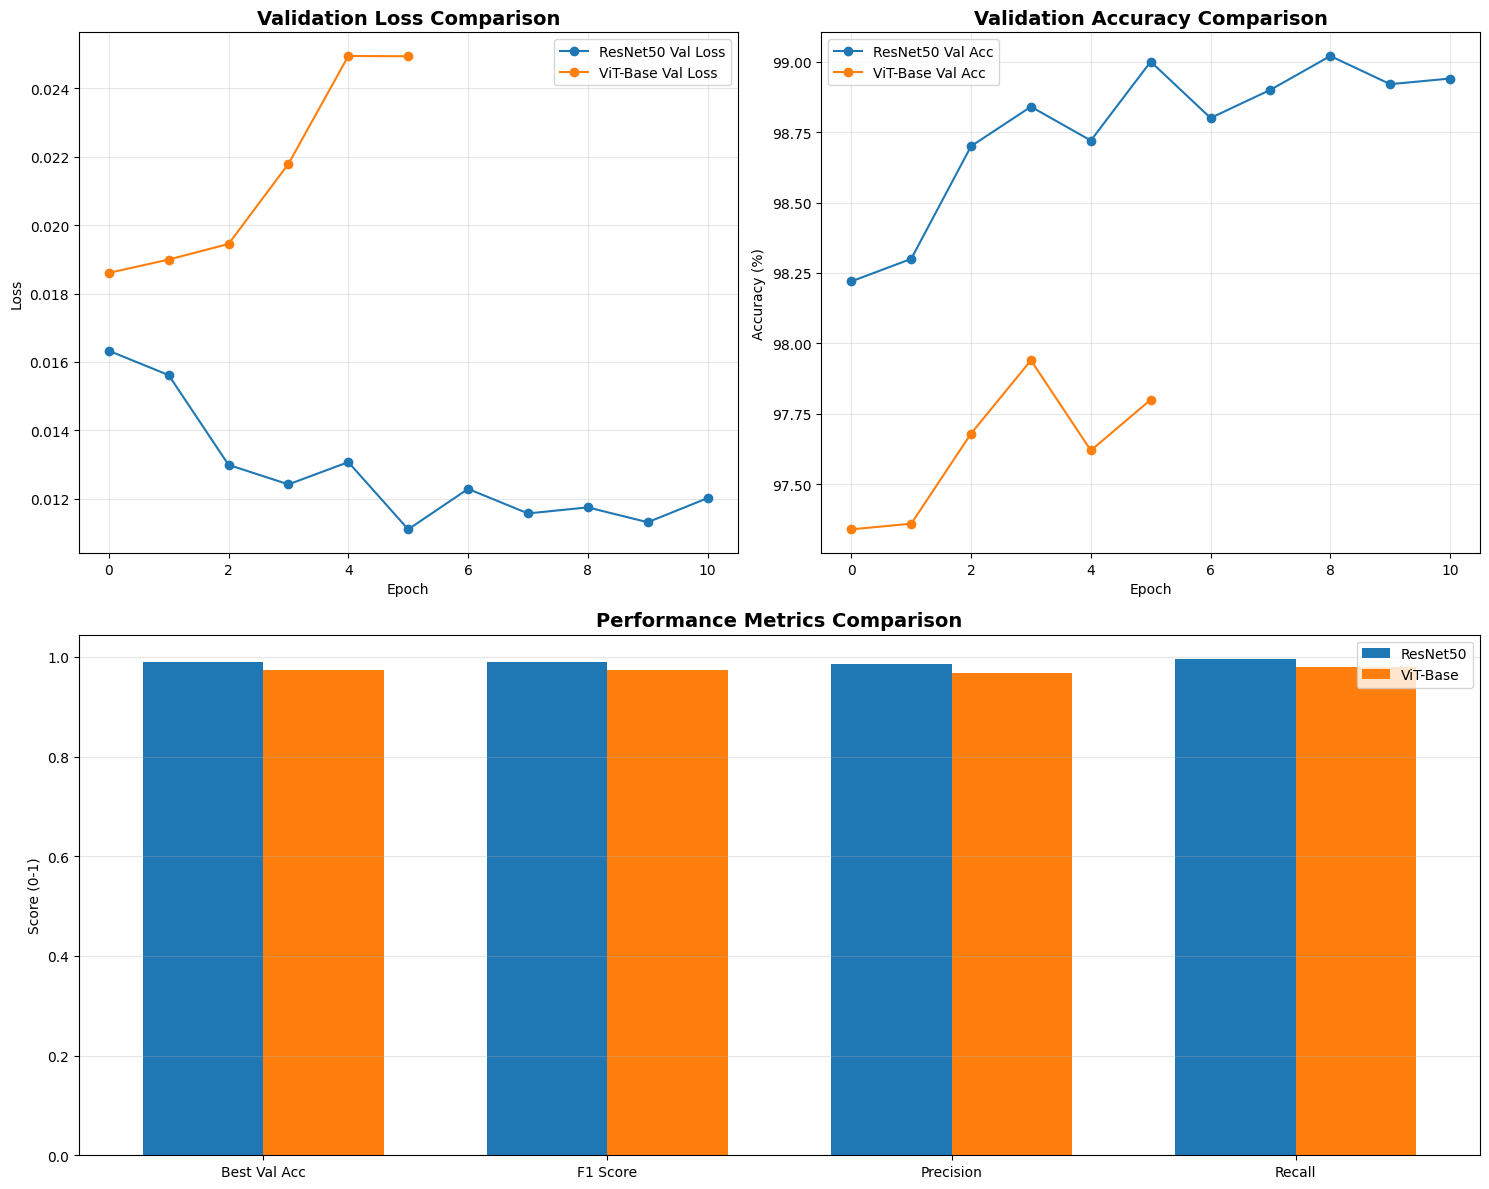

In [6]:
# 可视化不同模型在验证集上的损失、精度与综合指标对比
import pandas as pd

# 1. 汇总各模型的最优指标到表格中
comparison_data = []
for name, res in experiment_results.items():
    metrics = res['metrics']
    comparison_data.append({
        'Model': name,
        'Best Val Acc': res['best_val_acc'],
        'Best Val Loss': res['best_val_loss'],
        'Precision': metrics['precision'],
        'Recall': metrics['recall'],
        'F1 Score': metrics['f1_score']
    })

df_comparison = pd.DataFrame(comparison_data)
print("\nModel Comparison Summary:")
# 以 markdown 表格形式打印比较结果
print(df_comparison.to_markdown(index=False))

# 2. 画出验证集 Loss / Accuracy 曲线以及柱状图对比
plt.figure(figsize=(15, 12))

# Loss Comparison：验证损失曲线
plt.subplot(2, 2, 1)
for name, res in experiment_results.items():
    plt.plot(res['history']['val_loss'], label=f'{name} Val Loss', marker='o')
plt.title('Validation Loss Comparison', fontsize=14, fontweight='bold')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True, alpha=0.3)

# Accuracy Comparison：验证精度曲线
plt.subplot(2, 2, 2)
for name, res in experiment_results.items():
    plt.plot(res['history']['val_acc'], label=f'{name} Val Acc', marker='o')
plt.title('Validation Accuracy Comparison', fontsize=14, fontweight='bold')
plt.xlabel('Epoch')
plt.ylabel('Accuracy (%)')
plt.legend()
plt.grid(True, alpha=0.3)

# Bar Chart for Metrics：用柱状图对比 ACC / F1 / Precision / Recall
plt.subplot(2, 1, 2)
metrics_to_plot = ['Best Val Acc', 'F1 Score', 'Precision', 'Recall']
x = np.arange(len(metrics_to_plot))
width = 0.35

for i, (name, res) in enumerate(experiment_results.items()):
    vals = [
        res['best_val_acc'] / 100,  # 精度转为 0-1 区间
        res['metrics']['f1_score'],
        res['metrics']['precision'],
        res['metrics']['recall']
    ]
    plt.bar(x + i*width - width/2, vals, width, label=name)

plt.ylabel('Score (0-1)')
plt.title('Performance Metrics Comparison', fontsize=14, fontweight='bold')
plt.xticks(x, metrics_to_plot)
plt.legend()
plt.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

### 5.2 验证集误差分析与可视化

这一部分对每个模型在验证集上的预测结果进行更细粒度的分析：
- 载入对应的最佳权重文件
- 计算混淆矩阵并可视化
- 统计误分类样本比例，并将部分误分类样本可视化，辅助理解模型的错误模式


==================== Detailed Analysis for: ResNet50 ====================


Analyzing val_set (ResNet50):   0%|          | 0/157 [00:00<?, ?it/s]

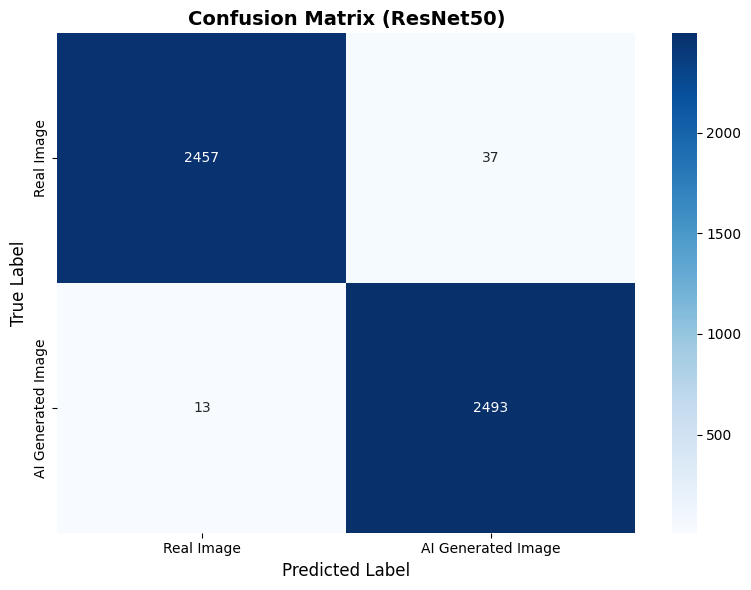


Misclassified Samples Analysis (ResNet50):
  - Total Errors: 50 / 5000 (1.00%)


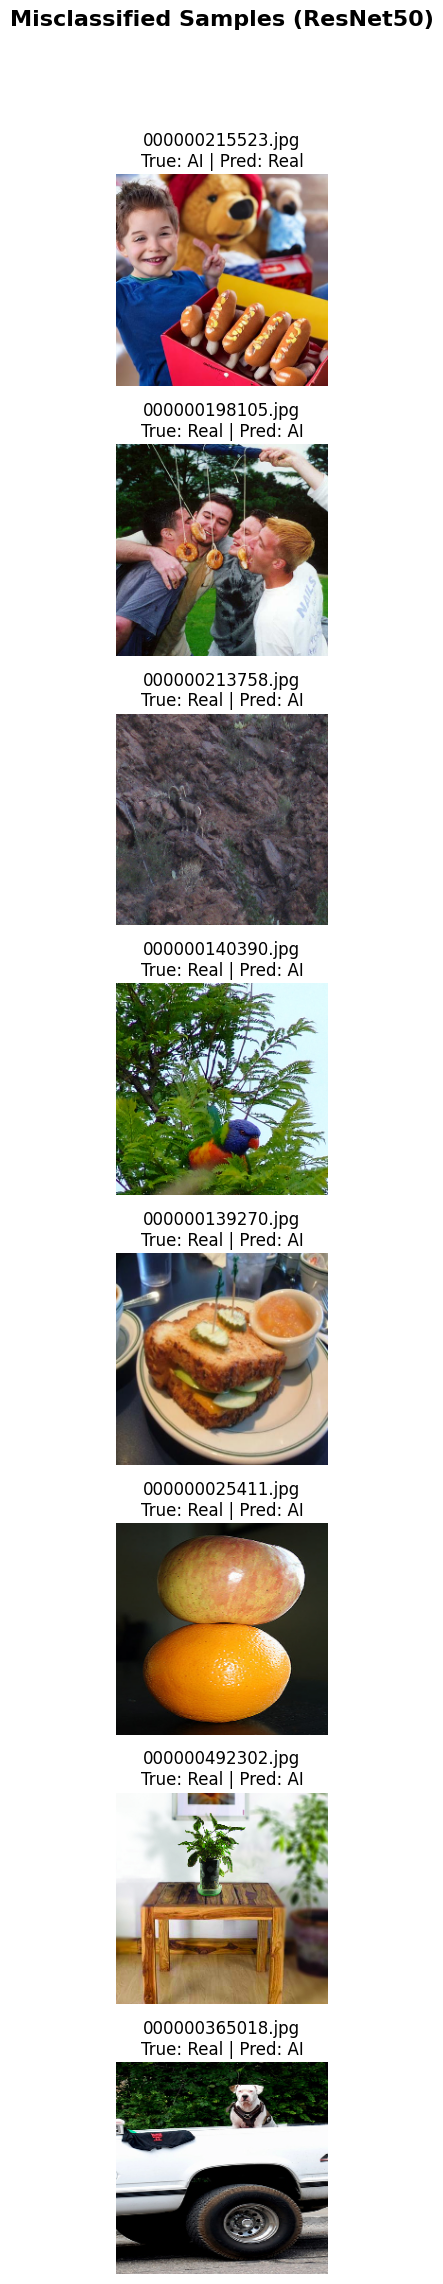


==================== Detailed Analysis for: ViT-Base ====================


Analyzing val_set (ViT-Base):   0%|          | 0/157 [00:00<?, ?it/s]

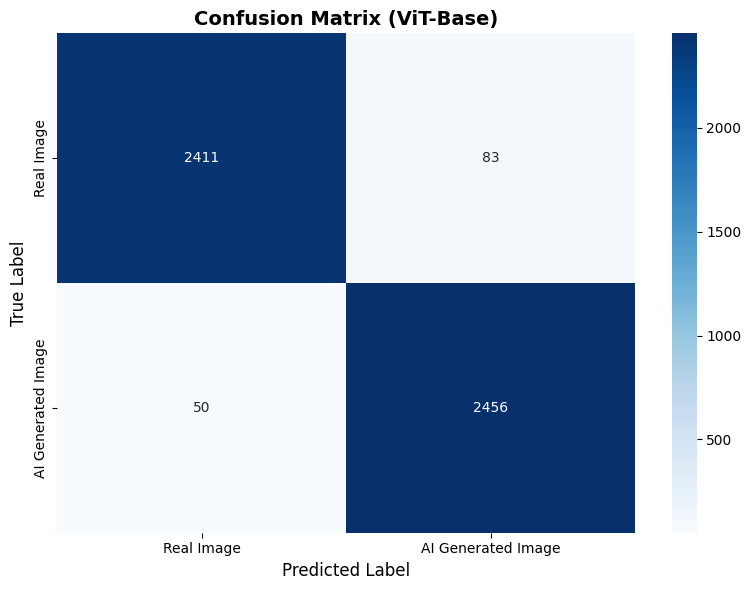


Misclassified Samples Analysis (ViT-Base):
  - Total Errors: 133 / 5000 (2.66%)


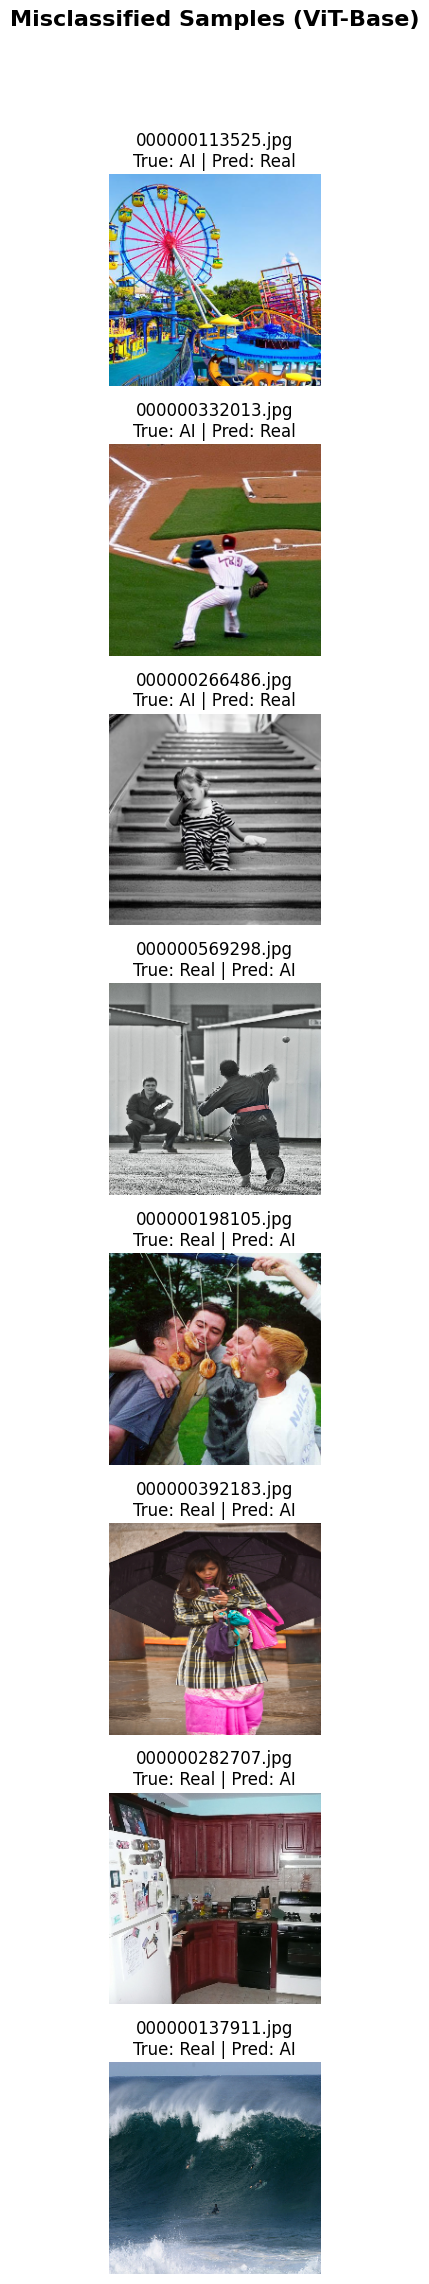

In [7]:
# 在验证集上对所有模型做详细误差分析与可视化
from sklearn.metrics import confusion_matrix
import seaborn as sns

for model_name in experiment_results.keys():
    print(f"\n{'='*20} Detailed Analysis for: {model_name} {'='*20}")

    # 根据名称构建相同结构的模型（不再下载预训练权重）
    if model_name == 'ViT-Base':
        model = ViTForAIGC(num_classes=2, pretrained=False)
    elif model_name == 'ResNet50':
        model = ResNetForAIGC(num_classes=2, pretrained=False)
    
    # 加载该模型在训练过程中保存的最优 checkpoint
    best_ckpt_path = experiment_results[model_name]['checkpoint_path']
    checkpoint = torch.load(best_ckpt_path, map_location=device, weights_only=False)
    model.load_state_dict(checkpoint['model_state_dict'])
    model = model.to(device)
    model.eval()

    # 在验证集上收集预测结果与真实标签
    all_preds = []
    all_labels = []
    all_filenames = []
    misclassified_samples = []  # 保存误分类样本信息

    with torch.no_grad():
        for batch in tqdm(dataloaders['val'], desc=f'Analyzing val_set ({model_name})'):
            rgb_images = batch['rgb'].to(device)
            labels = batch['label'].to(device)
            filenames = batch['filename']
            
            outputs = model(rgb_images)
            logits = outputs['logits']
            
            # 取最大概率对应类别作为预测
            _, predicted = torch.max(logits.data, 1)
            
            # 记录整体预测结果
            all_preds.extend(predicted.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())
            all_filenames.extend(filenames)
            
            # 识别当前 batch 中的误分类样本
            incorrect_mask = (predicted != labels)
            if incorrect_mask.any():
                incorrect_indices = torch.where(incorrect_mask)[0]
                for idx in incorrect_indices:
                    misclassified_samples.append({
                        'filename': filenames[idx],
                        'true_label': labels[idx].item(),
                        'predicted_label': predicted[idx].item(),
                        'rgb_image': rgb_images[idx].cpu()
                    })

    # 计算并可视化混淆矩阵
    cm = confusion_matrix(all_labels, all_preds)
    plt.figure(figsize=(8, 6))
    sns.heatmap(
        cm, annot=True, fmt='d', cmap='Blues',
        xticklabels=['Real Image', 'AI Generated Image'],
        yticklabels=['Real Image', 'AI Generated Image']
    )
    plt.title(f'Confusion Matrix ({model_name})', fontsize=14, fontweight='bold')
    plt.xlabel('Predicted Label', fontsize=12)
    plt.ylabel('True Label', fontsize=12)
    plt.tight_layout()
    plt.show()

    # 输出误分类样本统计信息
    print(f"\nMisclassified Samples Analysis ({model_name}):")
    print(f"  - Total Errors: {len(misclassified_samples)} / {len(all_labels)} ({len(misclassified_samples)/len(all_labels)*100:.2f}%)")

    # 可视化部分误分类样本，方便观察错误模式
    if misclassified_samples:
        fig, axes = plt.subplots(min(8, len(misclassified_samples)), 1, figsize=(6, 3*min(8, len(misclassified_samples))))
        if len(misclassified_samples) == 1:
            axes = [axes]
        plt.suptitle(f'Misclassified Samples ({model_name})', fontsize=16, fontweight='bold')
        
        for i, sample in enumerate(misclassified_samples[:8]):
            # 反归一化 RGB 图像到 [0, 1] 范围
            rgb_img = sample['rgb_image'].permute(1, 2, 0).numpy()
            rgb_img = rgb_img * np.array([0.229, 0.224, 0.225]) + np.array([0.485, 0.456, 0.406])
            rgb_img = np.clip(rgb_img, 0, 1)
            
            ax = axes[i]
            ax.imshow(rgb_img)
            ax.set_title(
                f"{sample['filename']}\nTrue: {'AI' if sample['true_label'] == 1 else 'Real'} | Pred: {'AI' if sample['predicted_label'] == 1 else 'Real'}"
            )
            ax.axis('off')
        
        plt.tight_layout(rect=[0, 0.03, 1, 0.95])
        plt.show()

## 6. Save configuration

### 6.1 保存各模型训练配置与指标

本部分会：
- 根据比较结果选出验证集表现最好的模型
- 为每个模型生成对应的配置文件（JSON），记录训练超参数与指标信息
- 指出每个模型的最佳权重所在路径，方便后续加载与推理

In [8]:
# 为所有模型保存训练配置与指标，便于后续复现与对比
import shutil

# 序列化辅助函数：将 numpy / torch 类型转为 Python 内置类型，方便 json.dump
def to_serializable(obj):
    import numpy as np
    import torch
    if isinstance(obj, (np.floating, np.integer)):
        return obj.item()
    if isinstance(obj, torch.Tensor):
        return obj.item()
    return obj

# 根据最佳验证精度选出整体最优模型
best_model_name = df_comparison.loc[df_comparison['Best Val Acc'].idxmax()]['Model']
print(f"Overall Best Model: {best_model_name}")

for model_name, res in experiment_results.items():
    print(f"\nSaving configuration for {model_name}...")
    
    # 将 metrics 中的值转为 float，确保可 JSON 序列化
    metrics_serializable = {
        k: float(v) if not isinstance(v, (list, dict)) else v
        for k, v in res['metrics'].items()
    }

    # 汇总该模型的训练配置信息与最佳指标
    config = {
        'model_name': model_name,
        'training_date': time.strftime('%Y-%m-%d %H:%M:%S'),
        'training_duration_minutes': float(total_duration / 60),
        'best_epoch': int(res['best_epoch']),
        'best_val_acc': float(res['best_val_acc']),
        'best_val_loss': float(res['best_val_loss']),
        'metrics': metrics_serializable,
        'training_config': {
            'batch_size': int(BATCH_SIZE),
            'epochs': int(EPOCHS),
            'optimizer': 'AdamW',
            'loss_function': 'FocalLoss(alpha=0.75, gamma=2.0)'
        },
        # 标记该模型是否是本次实验的“优胜者”
        'is_winner': (model_name == best_model_name)
    }

    # 将配置保存为 JSON 文件，文件名中带模型名称
    config_filename = f'training_config_{model_name}.json'
    with open(os.path.join(CHECKPOINT_DIR, config_filename), 'w') as f:
        json.dump(config, f, indent=2)
    print(f"  -> Saved config: {config_filename}")

    # 模型权重已在训练阶段重命名好，这里仅做路径提示
    print(f"  -> Model weights located at: {res['checkpoint_path']}")

print("\nConfiguration and model saving complete.")

Overall Best Model: ResNet50

Saving configuration for ResNet50...
  -> Saved config: training_config_ResNet50.json
  -> Model weights located at: checkpoints/best_model_ResNet50.pth

Saving configuration for ViT-Base...
  -> Saved config: training_config_ViT-Base.json
  -> Model weights located at: checkpoints/best_model_ViT-Base.pth

Configuration and model saving complete.
